# **[캐글 필사]**

https://www.kaggle.com/code/sudalairajkumar/simple-exploration-notebook-instacart 

목적: 고객의 과거 주문 데이터를 바탕으로 다음 주문에 어떤 상품을 다시 구매(Re-order)할지 예측
-20만 명 이상의 Instacart 사용자, 300만 건 이상의 장바구니 주문 데이터

데이터 구조: 고객별 주문 이력(orders), 주문별 포함 상품 및 장바구니 담긴 순서(order_products), 상품명(products), 카테고리(aisles), 부서(departments)로 구성된 관계형 데이터

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None  # default='warn'

In [6]:
order_products_train_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/order_products__train.csv")
order_products_prior_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/order_products__prior.csv")

In [7]:
orders_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/orders.csv")
products_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/products.csv")
aisles_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/aisles.csv")
departments_df = pd.read_csv("C:/Users/user/ESAA_YB/3주차캐글필사/departments.csv")

## 데이터 

order_products_train_df : 학습용 주문 데이터 (train set)
order_products_prior_df : 과거 주문 데이터
orders_df : 주문데이터
products_df : 상품 데이터
aisles_df : 소분류 데이터
departments_df : 대분류/부서 데이터 

In [17]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [18]:
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [19]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


주문데이터의 eval_set 컬럼에 대해 막대그래프 시각화
-value_counts() 사용
-barplot : alpha인자는 그래프의 투명도 조절
-label : fontsize 지정
-title : fontsize 지정 
-ticks : 눈금 관련, rotation인자로 회전. 아래에서 xticks()로 x축 눈금이 90도 회전함 

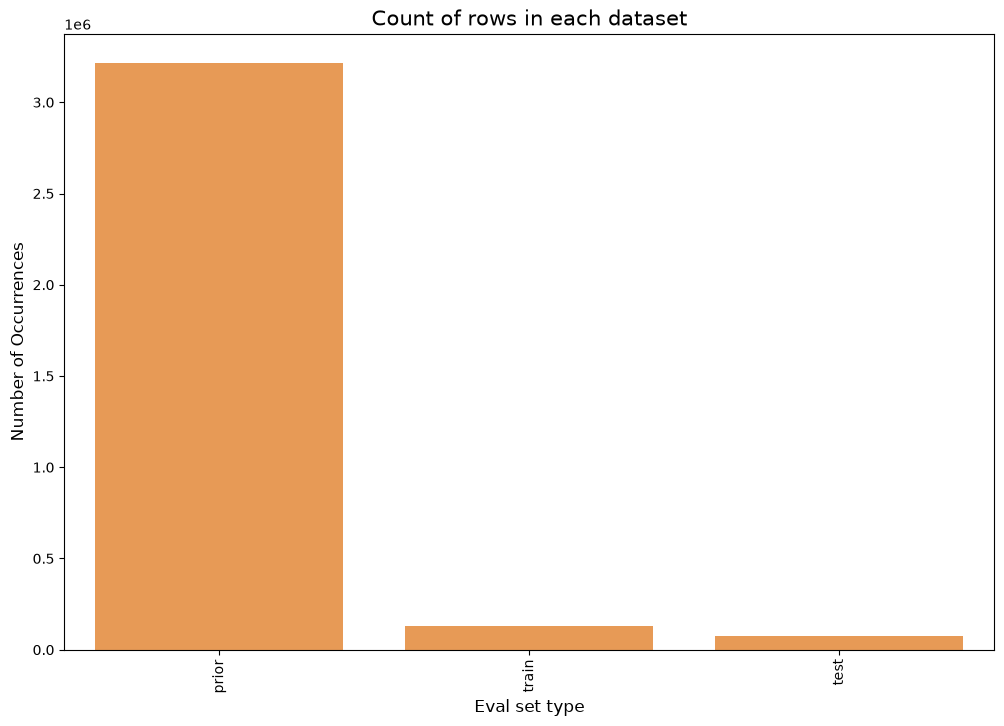

In [23]:
cnt_srs = orders_df.eval_set.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[1])

plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Eval set type', fontsize=12)
plt.title('Count of rows in each dataset', fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

-중복을 제거한 값들을 구하는 함수를 정의 
-len()로 중복제거값들의 총 개수 리턴
-groupby()로 주문 데이터를 eval_set별로 그룹화, user_id만 불러오고 위 함수를 적용하여 고객이 몇명인지 알아봄


In [21]:
def get_unique_count(x):
    return len(np.unique(x))

cnt_srs = orders_df.groupby("eval_set")["user_id"].aggregate(get_unique_count)
cnt_srs

eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

최대 주문 횟수별 고객수를 막대그래프로 시각화 

-groupby : 주문 데이터를 user_id별로 그룹화, order_number만 불러옴
-aggregate : order_number의 max값 -> 고객별 총 주문횟수 구함 
-reset_index() : 인덱스를 재정의하여 user_id, order_number 두 컬럼의 새로운 df 변환 

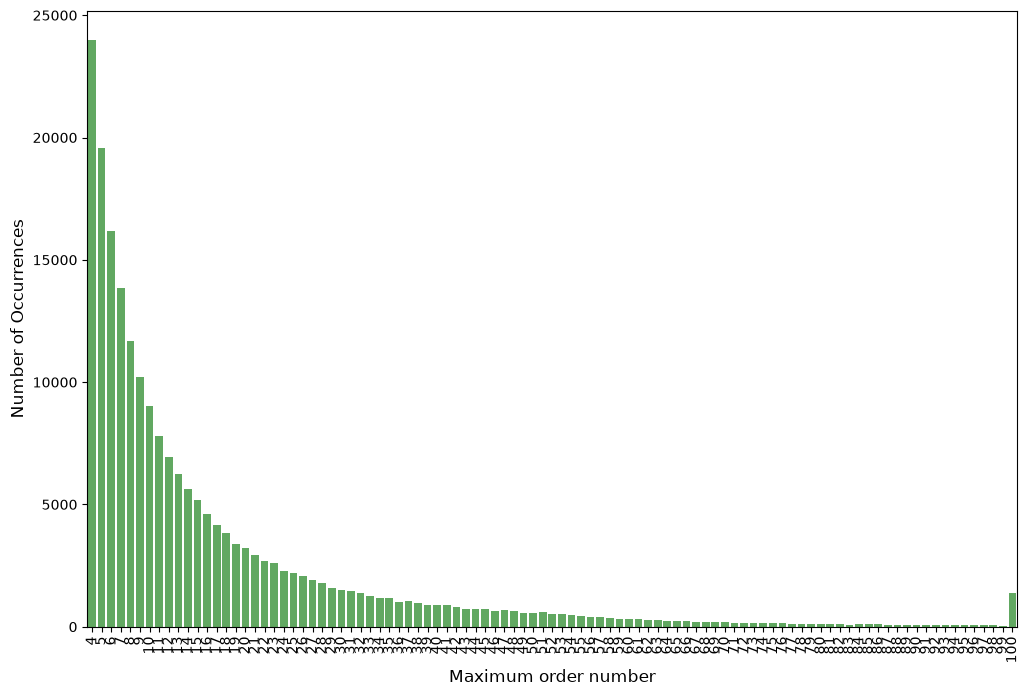

In [24]:
cnt_srs = orders_df.groupby("user_id")["order_number"].aggregate(np.max).reset_index()
cnt_srs = cnt_srs.order_number.value_counts() #고객별 최대 주문 횟수의 분포를 계산 

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[2])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Maximum order number', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

요일별 주문 건수의 countplot 시각화 
-x축 : 요일, 0=일요일 1=월요일
-sns.countplot() : 시본으로 x축의 빈도수 자동 계산 


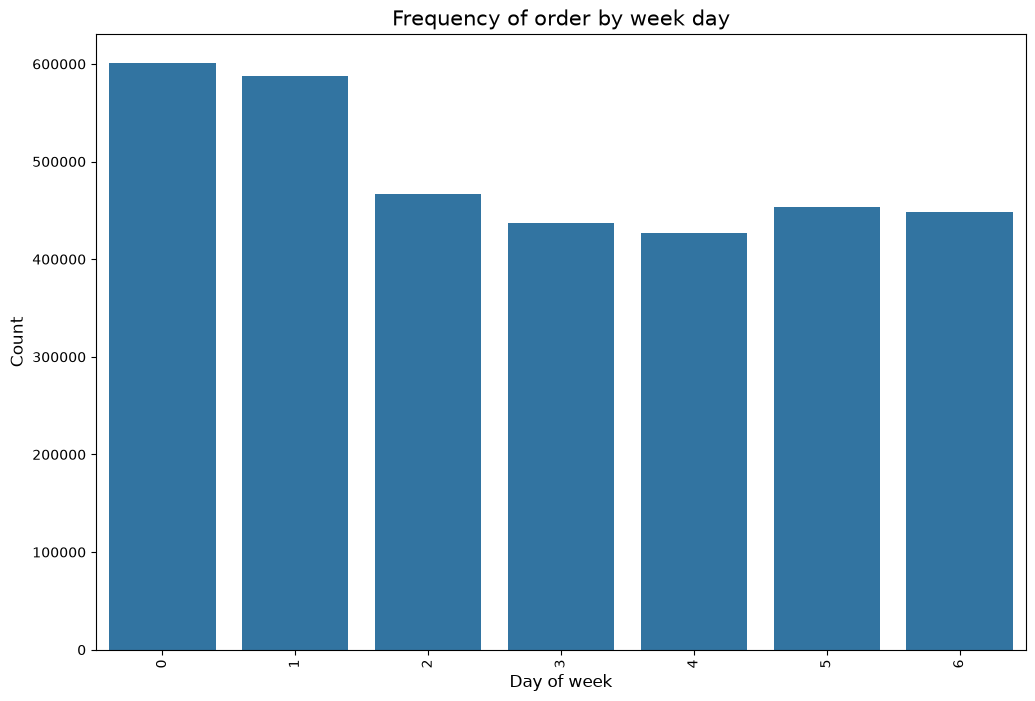

In [25]:
plt.figure(figsize=(12,8))
sns.countplot(x="order_dow", data=orders_df, color=color[0])
plt.ylabel('Count', fontsize=12)
plt.xlabel('Day of week', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by week day", fontsize=15)
plt.show()

시간대별 주문 건수를 countplot으로 시각화 

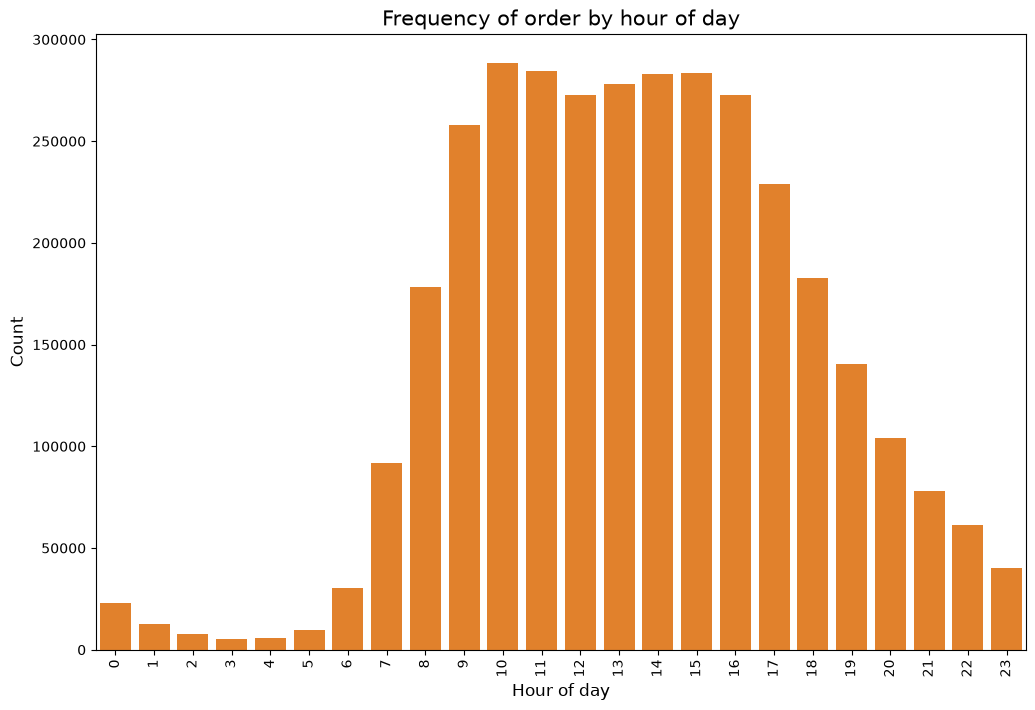

In [26]:
plt.figure(figsize=(12,8))
sns.countplot(x="order_hour_of_day", data=orders_df, color=color[1])
plt.ylabel('Count', fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by hour of day", fontsize=15)
plt.show()

In [ ]:
요일과 시간대의 각 조합별 총 주문 건수 히트맵

-pivot : 히트맵을 위해 격자형태로 재배치, index인자로 요일을 행(세로축)으로 설정, 
column인자로 시간대를 열(가로축) 설정, values 인자로 각 칸 내부를 주문건수로 채움 

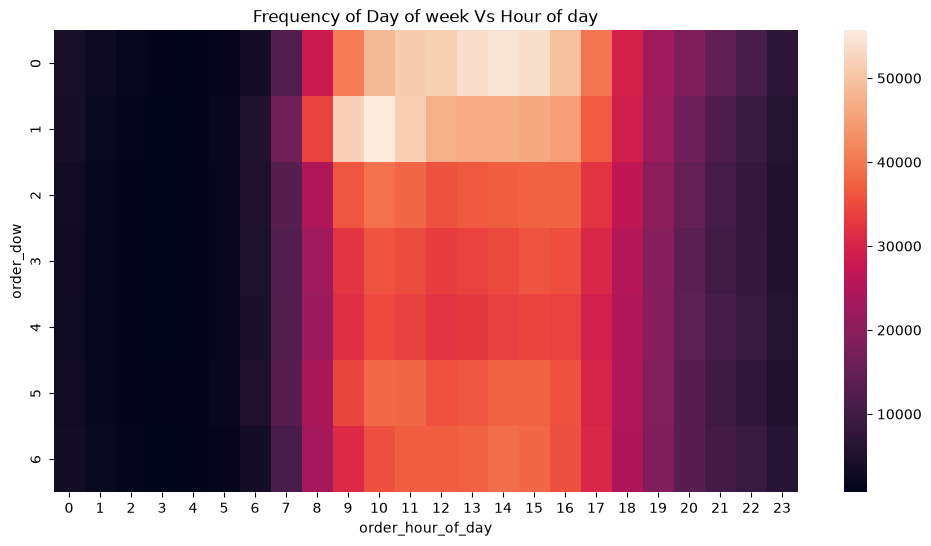

In [27]:
grouped_df = orders_df.groupby(["order_dow", "order_hour_of_day"])["order_number"].aggregate("count").reset_index()
grouped_df = grouped_df.pivot(index='order_dow',columns='order_hour_of_day', values='order_number')

plt.figure(figsize=(12,6))
sns.heatmap(grouped_df)
plt.title("Frequency of Day of week Vs Hour of day")
plt.show()

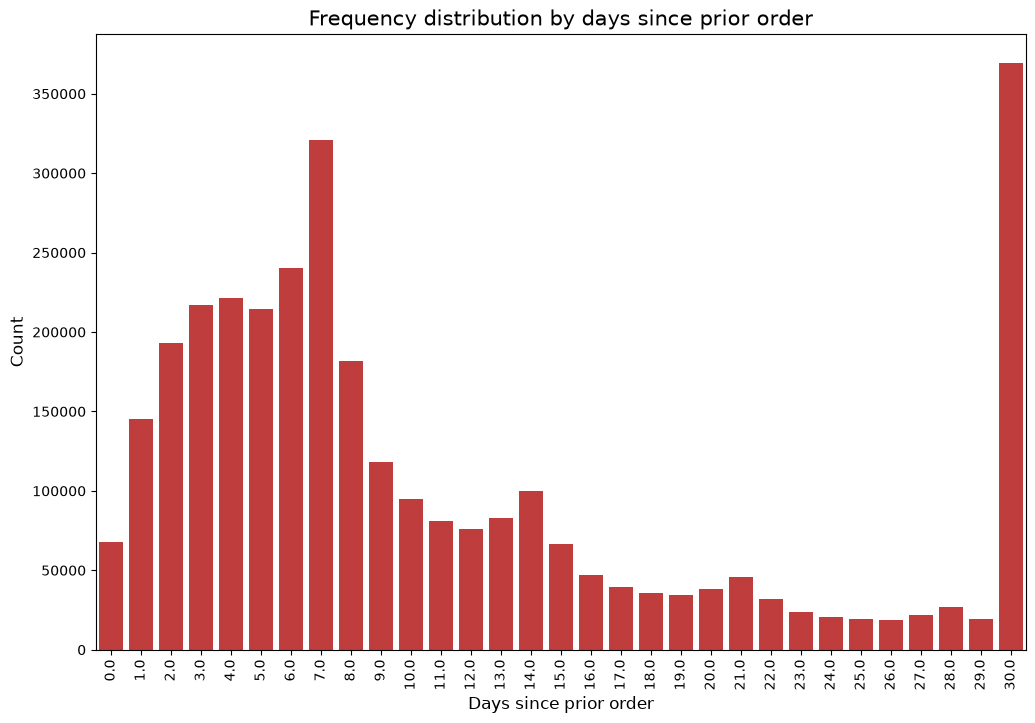

In [28]:
plt.figure(figsize=(12,8))
sns.countplot(x="days_since_prior_order", data=orders_df, color=color[3])
plt.ylabel('Count', fontsize=12)
plt.xlabel('Days since prior order', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency distribution by days since prior order", fontsize=15)
plt.show()

In [ ]:
reordered면 1로 설정되어서 1인 행들의 합을 구함 -> 재구매된 상품의 총 개수


In [29]:
# percentage of re-orders in prior set #
order_products_prior_df.reordered.sum() / order_products_prior_df.shape[0]

np.float64(0.5896974667922161)

In [30]:
# percentage of re-orders in train set #
order_products_train_df.reordered.sum() / order_products_train_df.shape[0]

np.float64(0.5985944127509629)

In [31]:
grouped_df = order_products_prior_df.groupby("order_id")["reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

C:\Users\user\AppData\Local\Temp\ipykernel_16072\3802815690.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


reordered
0      1.208486e-01
2      1.028874e-01
1      1.019940e-01
3      9.720225e-02
4      8.762521e-02
           ...     
107    3.110542e-07
79     3.110542e-07
77     3.110542e-07
81     3.110542e-07
114    3.110542e-07
Name: count, Length: 98, dtype: float64

In [33]:
grouped_df = order_products_train_df.groupby("order_id")["reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

C:\Users\user\AppData\Local\Temp\ipykernel_16072\1346010774.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


reordered
1     0.118117
2     0.112591
3     0.101220
4     0.091564
5     0.078684
        ...   
71    0.000008
52    0.000008
60    0.000008
65    0.000008
55    0.000008
Name: count, Length: 63, dtype: float64

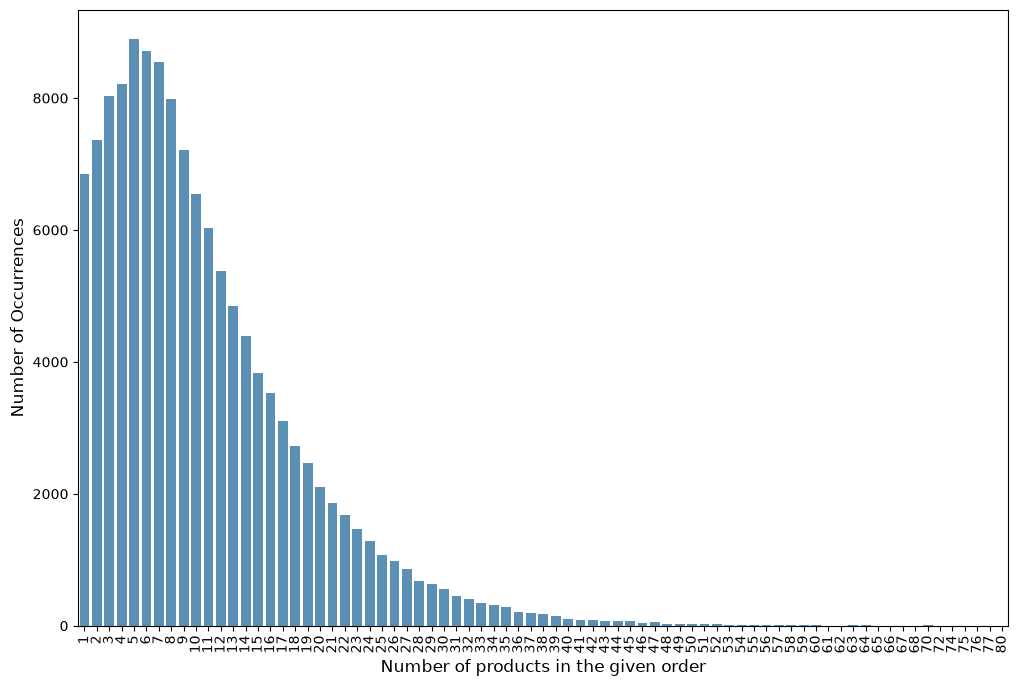

In [34]:
grouped_df = order_products_train_df.groupby("order_id")["add_to_cart_order"].aggregate("max").reset_index()
cnt_srs = grouped_df.add_to_cart_order.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Number of products in the given order', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

In [35]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [36]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [37]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [13]:
order_products_prior_df = pd.merge(order_products_prior_df, products_df, on='product_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles_df, on='aisle_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, departments_df, on='department_id', how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [39]:
cnt_srs = order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_srs.columns = ['product_name', 'frequency_count']
cnt_srs

,product_name,frequency_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


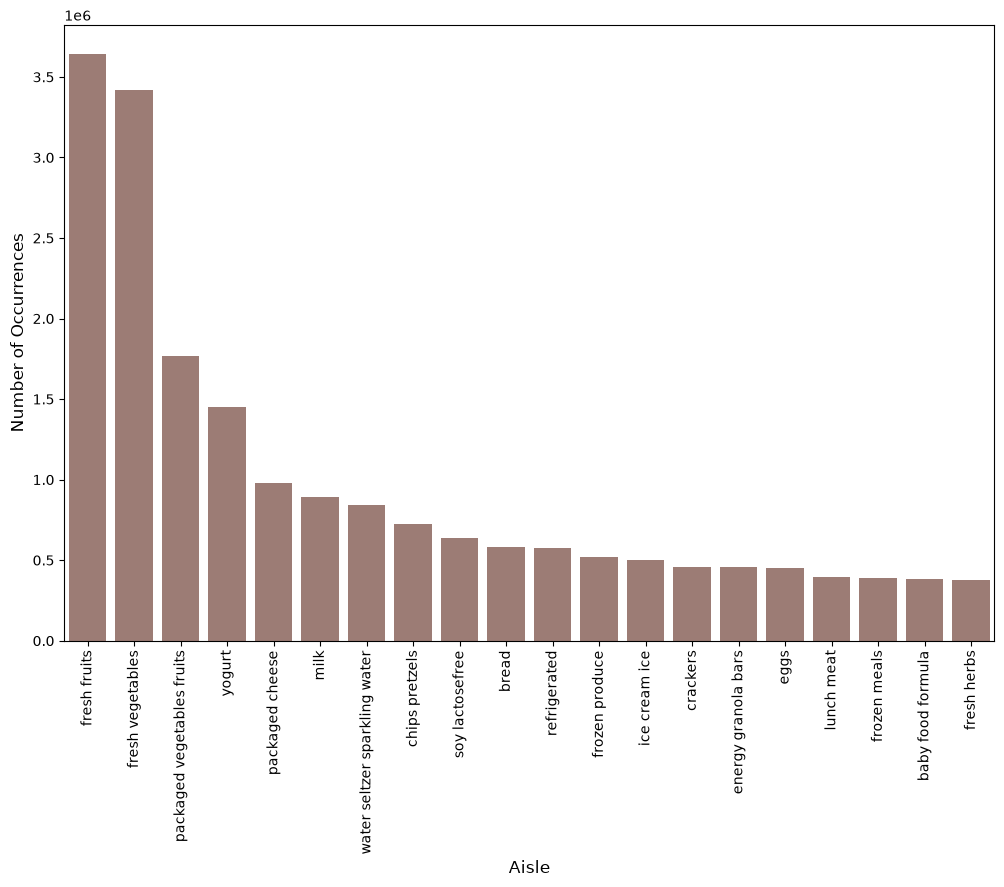

In [40]:
cnt_srs = order_products_prior_df['aisle'].value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[5])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Aisle', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

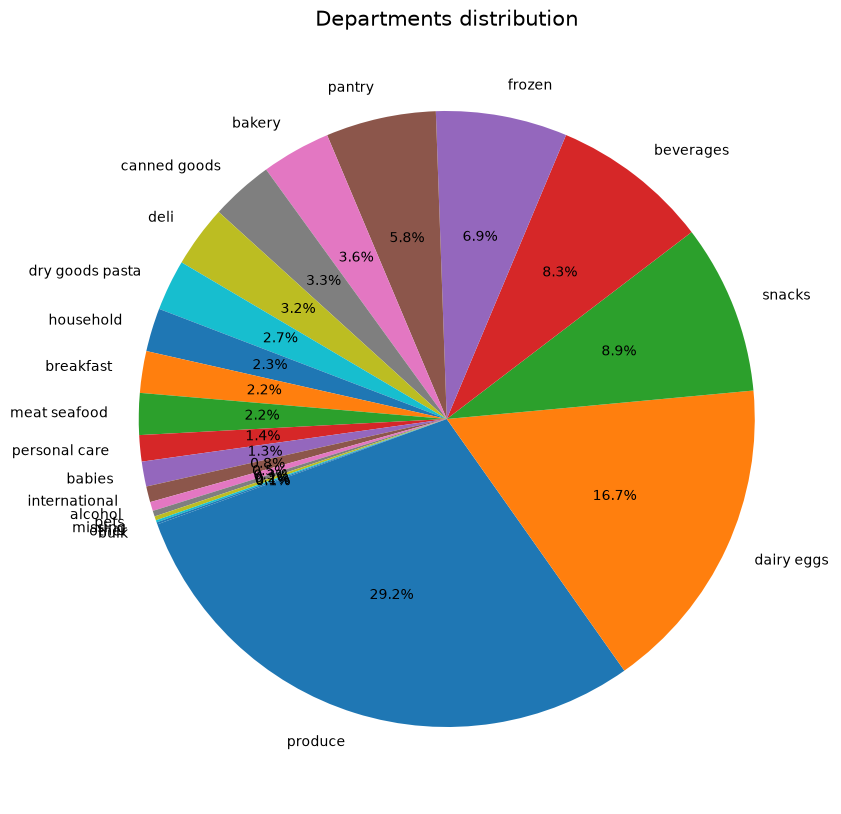

In [41]:
plt.figure(figsize=(10,10))
temp_series = order_products_prior_df['department'].value_counts()
labels = (np.array(temp_series.index))
sizes = (np.array((temp_series / temp_series.sum())*100))
plt.pie(sizes, labels=labels, 
        autopct='%1.1f%%', startangle=200)
plt.title("Departments distribution", fontsize=15)
plt.show()

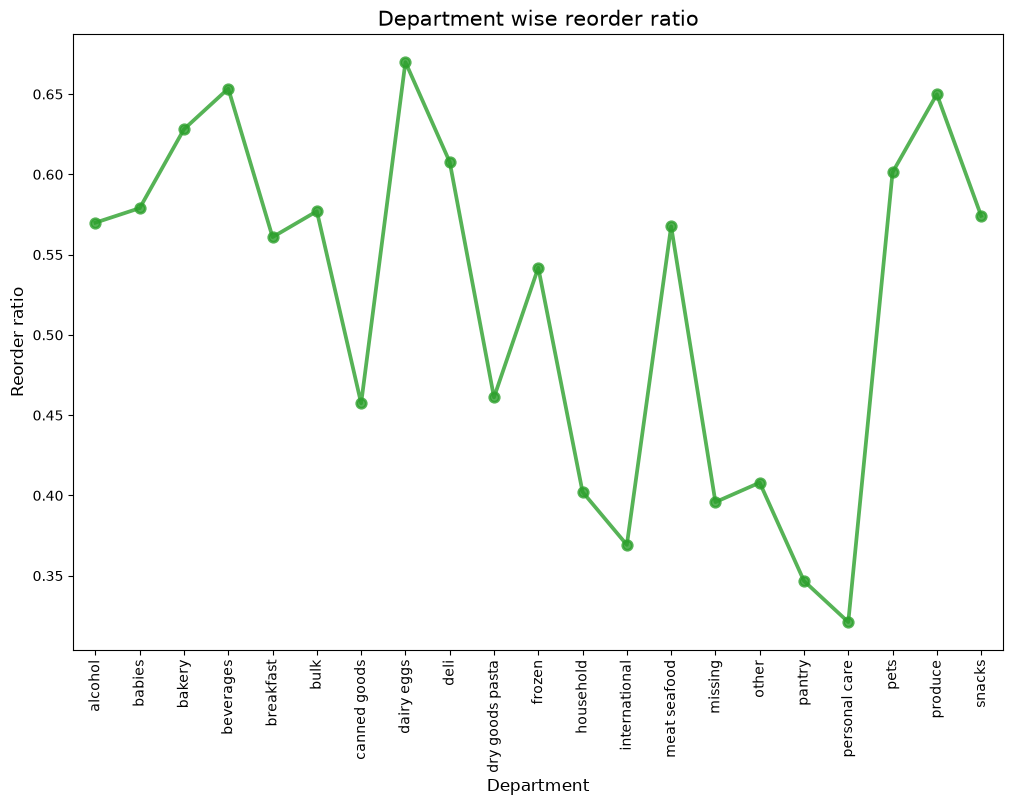

In [42]:
grouped_df = order_products_prior_df.groupby(["department"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['department'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.title("Department wise reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

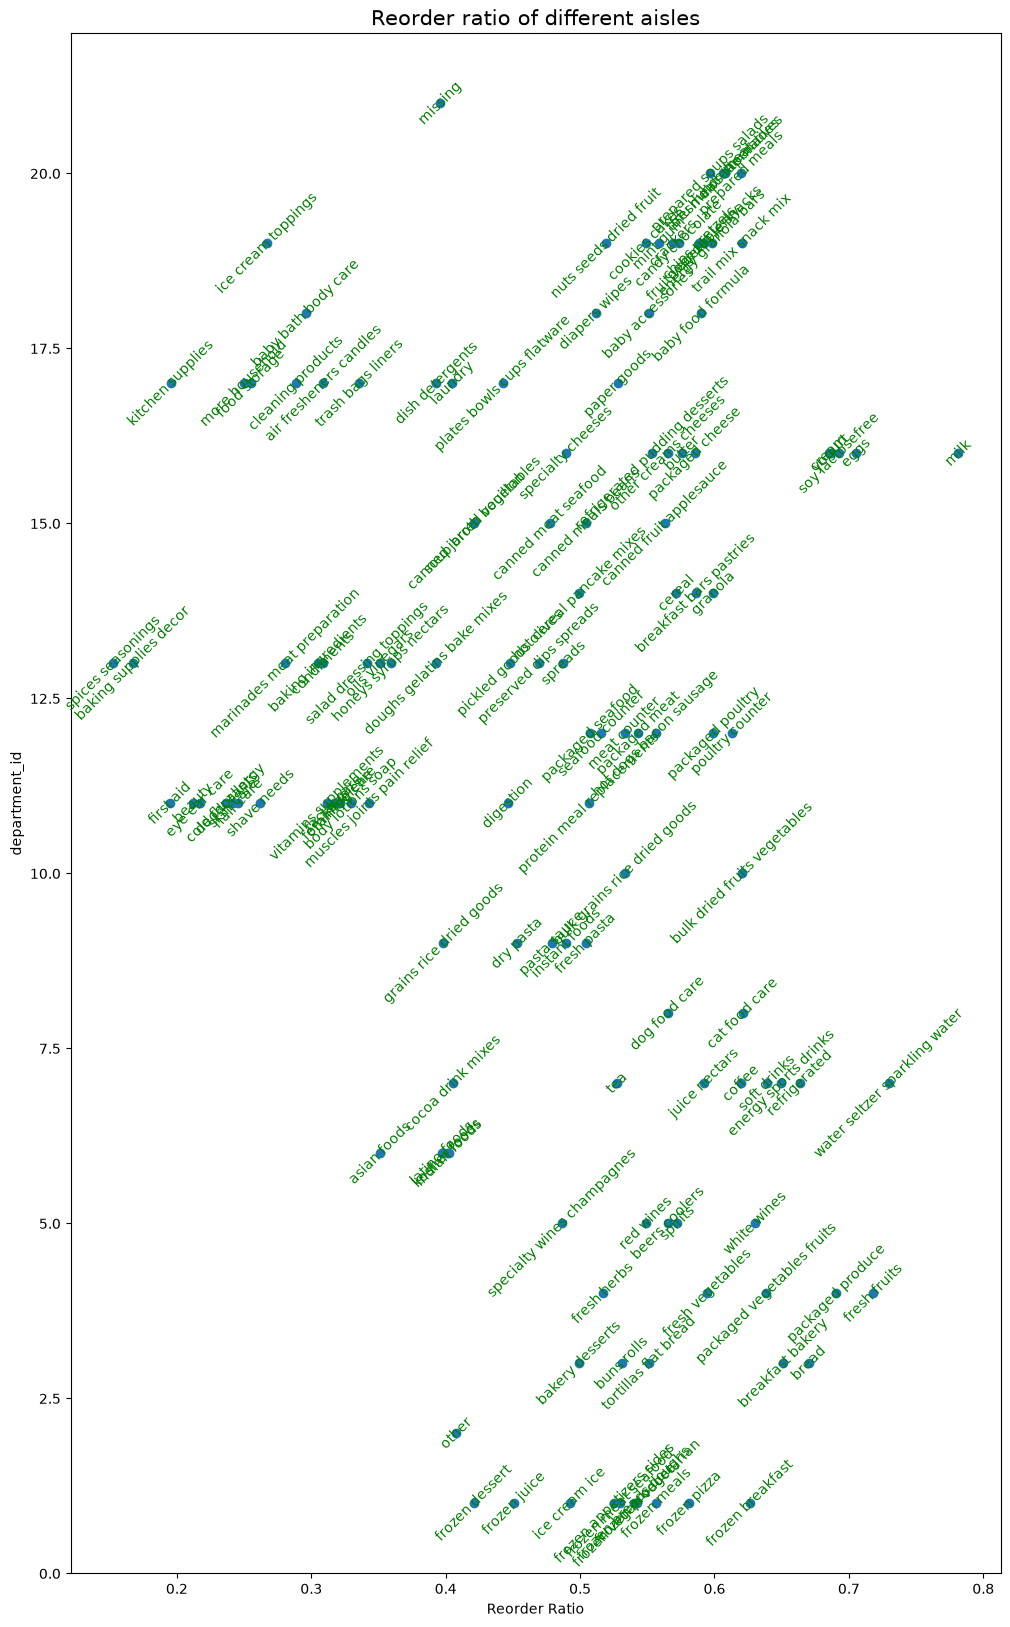

In [43]:
grouped_df = order_products_prior_df.groupby(["department_id", "aisle"])["reordered"].aggregate("mean").reset_index()

fig, ax = plt.subplots(figsize=(12,20))
ax.scatter(grouped_df.reordered.values, grouped_df.department_id.values)
for i, txt in enumerate(grouped_df.aisle.values):
    ax.annotate(txt, (grouped_df.reordered.values[i], grouped_df.department_id.values[i]), rotation=45, ha='center', va='center', color='green')
plt.xlabel('Reorder Ratio')
plt.ylabel('department_id')
plt.title("Reorder ratio of different aisles", fontsize=15)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16072\2317599065.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]> 70] = 70


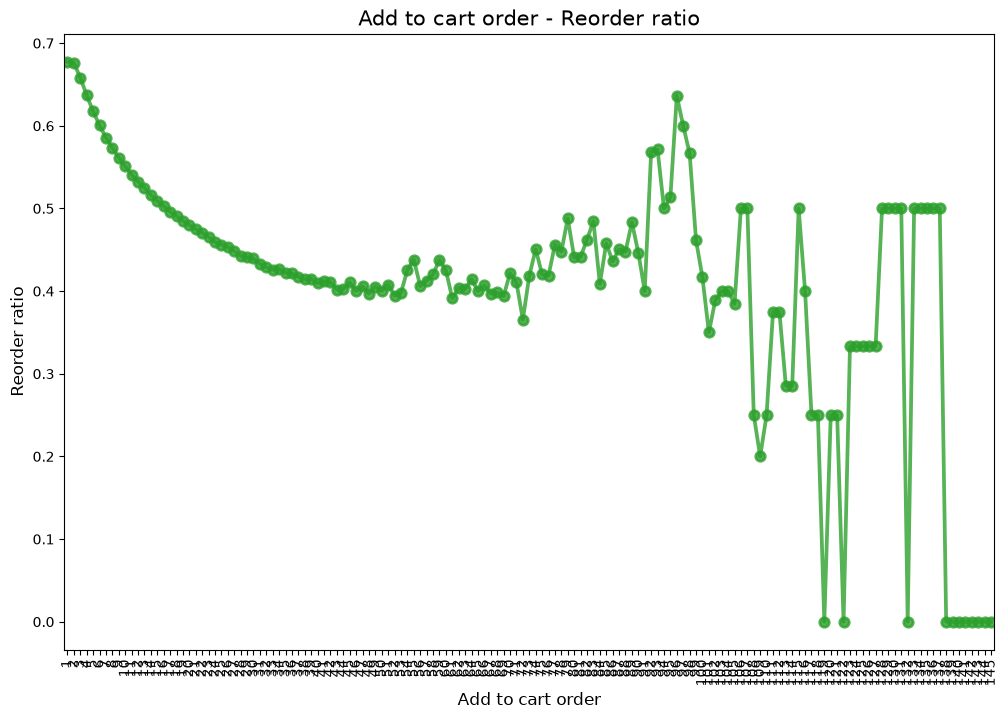

In [45]:
order_products_prior_df["add_to_cart_order_mod"] = order_products_prior_df["add_to_cart_order"].copy()
order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]> 70] = 70
grouped_df = order_products_prior_df.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['add_to_cart_order_mod'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Add to cart order', fontsize=12)
plt.title("Add to cart order - Reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

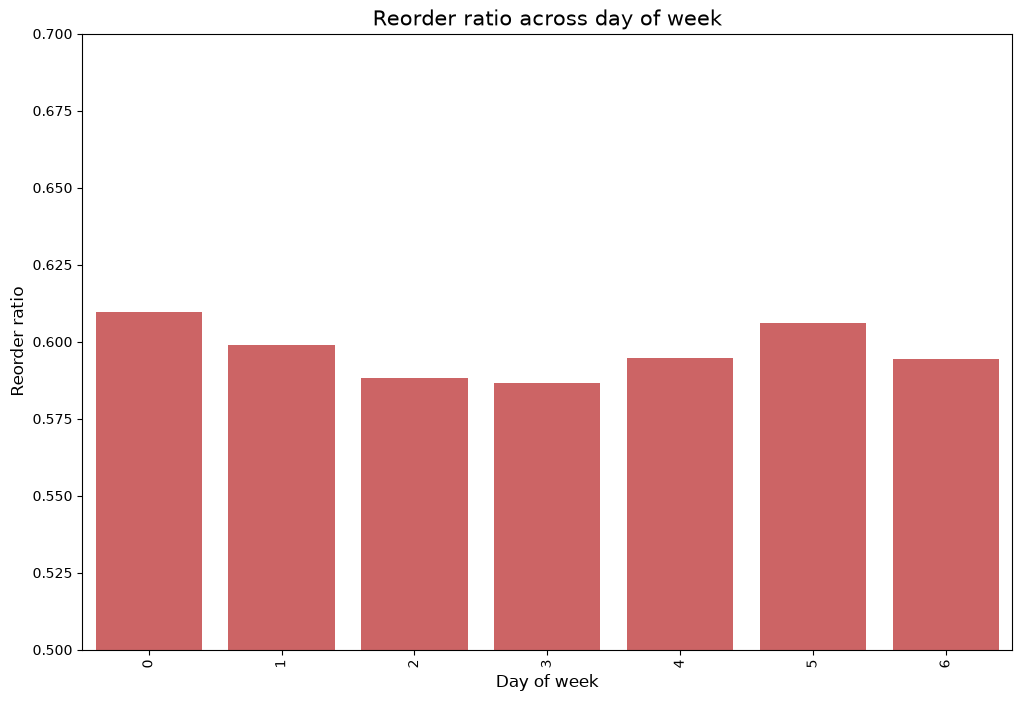

In [46]:
order_products_train_df = pd.merge(order_products_train_df, orders_df, on='order_id', how='left')
grouped_df = order_products_train_df.groupby(["order_dow"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_dow'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[3])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Day of week', fontsize=12)
plt.title("Reorder ratio across day of week", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

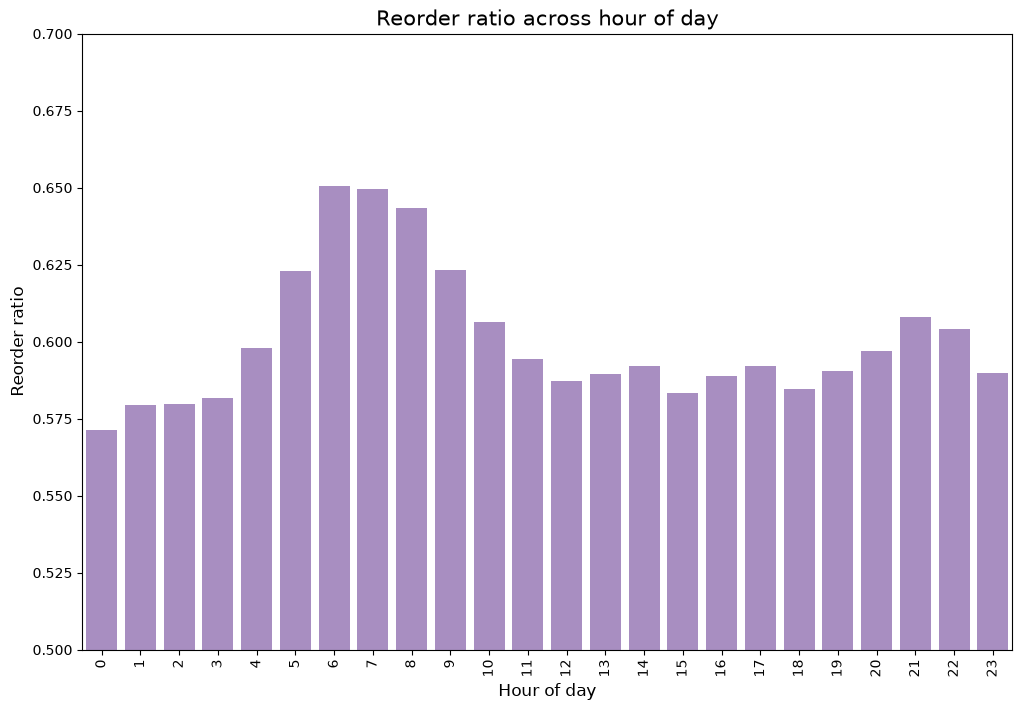

In [47]:
grouped_df = order_products_train_df.groupby(["order_hour_of_day"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_hour_of_day'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[4])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.title("Reorder ratio across hour of day", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

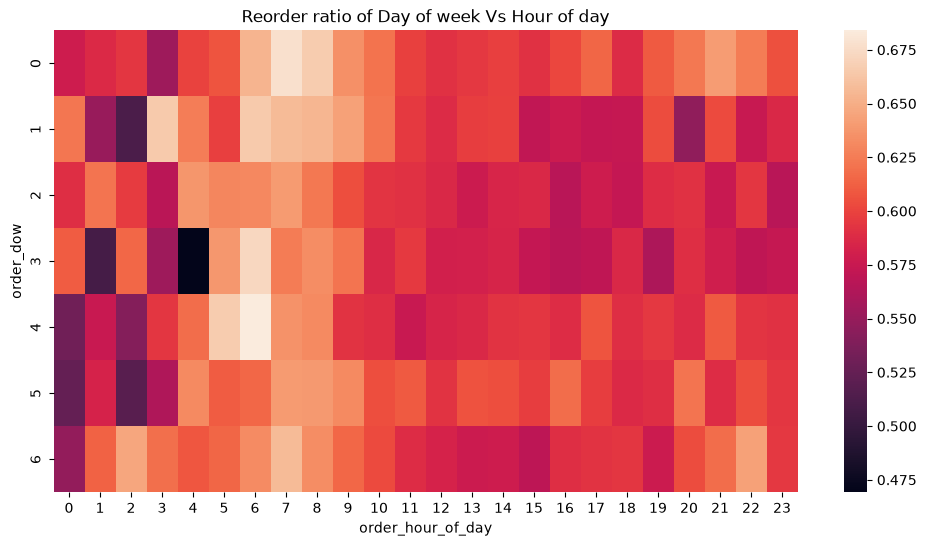

In [49]:
grouped_df = order_products_train_df.groupby(["order_dow", "order_hour_of_day"])["reordered"].aggregate("mean").reset_index()
grouped_df = grouped_df.pivot(index='order_dow',columns='order_hour_of_day', values='reordered')

plt.figure(figsize=(12,6))
sns.heatmap(grouped_df)
plt.title("Reorder ratio of Day of week Vs Hour of day")
plt.show()

# 새로운 전처리/시각화

고객별 평균 장바구니 크기 구하기
-고개별 한 번 주문할 때 평균 몇 개의 상품을 장바구니에 담는지

In [8]:
# 주문(order_id)별 담긴 상품 개수를 세고, 이를 고객(user_id) 기준으로 평균을 냅니다.
order_sizes = order_products_prior_df.groupby('order_id')['add_to_cart_order'].max().reset_index()
user_basket = pd.merge(orders_df[['order_id', 'user_id']], order_sizes, on='order_id')

user_avg_basket = user_basket.groupby('user_id')['add_to_cart_order'].mean().reset_index()
user_avg_basket.columns = ['user_id', 'avg_basket_size']

user_avg_basket.head()

,user_id,avg_basket_size
0,1,5.900000
1,2,13.928571
2,3,7.333333
3,4,3.600000
4,5,9.250000


In [ ]:
department별 평균 재구매율 막대그래프 시각화 


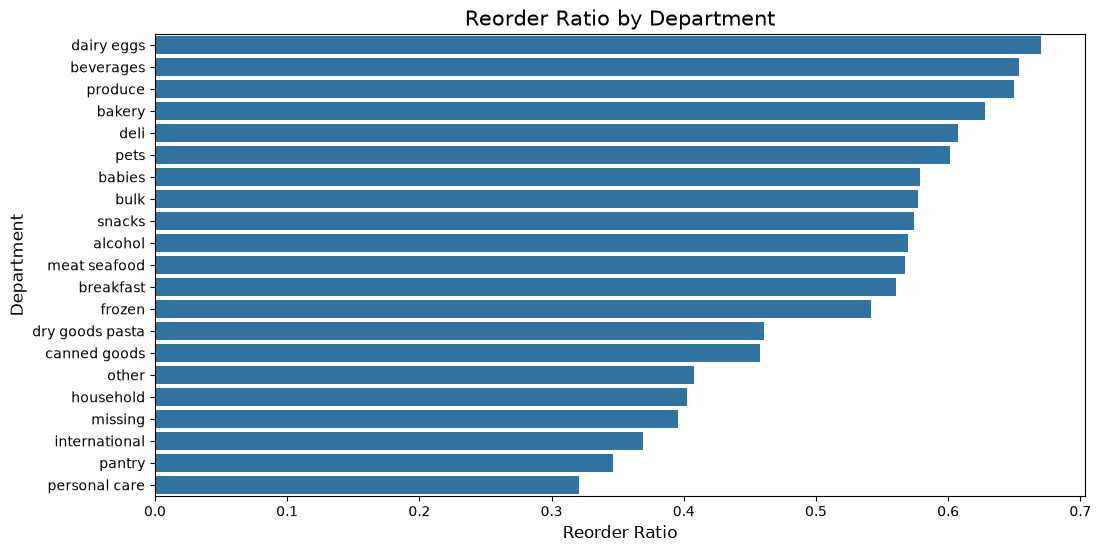

In [15]:
# 대분류별 평균 재구매율 계산 후 내림차순 정렬 (department 소문자로 수정)
dept_reorder = order_products_prior_df.groupby('department')['reordered'].mean().sort_values(ascending=False).reset_index()

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='reordered', y='department', data=dept_reorder)
plt.title('Reorder Ratio by Department', fontsize=15)
plt.xlabel('Reorder Ratio', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.show()